In [29]:
## pegasus env ##

import os
import gc
import glob
import random
import webbrowser

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns

import anndata as ad
import scanpy as sc

import plotly.graph_objects as go
import kaleido

## notebook viz 3#
import plotly.io as pio
pio.renderers.default = "notebook_connected"

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Note Stressed Glia is not large enough for statistical testing, 
#adata[adata.obs['subclass_annotations'] == 'Stressed Glia'].shape[0]
# 858 # despite contribution from multiple donors, manuscripts but dominated by Walsh/Studer MEL-1 line

4248

In [3]:
## Refrorm Categories as Str For Proper Coloring ##

adata.obs['subclass_annotations'] = adata.obs['subclass_annotations'].astype('str')
adata.obs['subclass_annotations_markers'] = adata.obs['subclass_annotations_markers'].astype('str')
adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].astype('str')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].astype('str')

In [4]:
## Correct CP / Choroid Plexus Distinction ##

adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].str.replace('Choroid Plexus ', 'CP-')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].str.replace('Choroid Plexus ', 'CP-')

In [5]:
## Set Categories So Colors Are Consistent ##

adata.obs['Manuscript'] = (adata.obs['Manuscript']
                         .astype('category').cat.set_categories(['Fernando', 'Khan', 'Notaras',
                                                                 'Purcell', 'Rao', 'Sawada', 'Sebastian',
                                                                 'Shin', 'Walsh']))

adata.obs['Protocol'] = (adata.obs['Protocol']
                         .astype('category').cat.set_categories(['Kadoshima', 'Kriegstein (Bhaduri)', 'Lancaster', 
                                                                 'Pasca (Sloan)', 'Pasca (Sloan) Ventral', 'Pasca (Yoon)']))

adata.obs['Chemistry'] = (adata.obs['Chemistry']
                         .astype('category').cat.set_categories(['10xv2', '10xv3', 'QuartzSeq2']))

adata.obs['Donor'] = (adata.obs['Donor']
                         .astype('category').cat.set_categories(['60C2', '0307', '0524', '581', '641', '972', '973', '2607', '2909',
                                                                  '3577-3', '5401-35', '6303', '7958', '9002-0031', '28126', 'C2320b',
                                                                  'C3141a', 'C8905a', 'C9632', 'DT1_A', 'DT1_U', 'H1', 'MEL-1',
                                                                  'MH0159019', 'MH0159020', 'MH0159021', 'MH0159025', 'MH0159026',
                                                                  'MH0159027', 'MH0167170', 'MH0200865', 'N0575a', 'N1884a', 'N3320a',
                                                                  'N9540a', 'Q1', 'Q2', 'Q5', 'Q6', 'WTC11']))

adata.obs['Sex'] = (adata.obs['Sex'].astype('category').cat.set_categories(['Female', 'Male']))

adata.obs['Broad_Genotype'] = (adata.obs['Broad_Genotype'].astype('category').cat.set_categories(['3q29del', '15q13.3del',
                                                                                                 '22q11.2del', 'Control',
                                                                                                 'Idiopathic_Schizophrenia', 
                                                                                                 'NRXN1del']))

In [6]:
## Colors ##

adata.uns['Manuscript_colors'] = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

adata.uns['Protocol_colors'] = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

adata.uns['Chemistry_colors'] = ['#1f77b4', '#ff7f0e', '#2ca02c']

adata.uns['Donor_colors'] = ['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46', '#008941', '#006fa6', 
                             '#a30059', '#ffdbe5', '#7a4900', '#0000a6', '#63ffac', '#b79762', 
                             '#004d43', '#8fb0ff', '#997d87', '#5a0007', '#809693', '#6a3a4c', 
                             '#1b4400', '#4fc601', '#3b5dff', '#4a3b53', '#ff2f80', '#61615a', 
                             '#ba0900', '#6b7900', '#00c2a0', '#ffaa92', '#ff90c9', '#b903aa', 
                             '#d16100', '#ddefff', '#000035', '#7b4f4b', '#a1c299', '#300018', 
                             '#0aa6d8', '#013349', '#00846f', '#372101']

adata.uns['Sex_colors'] = ['#1f77b4', '#ff7f0e']

adata.uns['Broad_Genotype_colors'] = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

In [7]:
adata.obs[['CellType', 'subtype_cluster_annotations_markers']]

,CellType,subtype_cluster_annotations_markers
barcodekey,,
SRR32261339_GAGCTGCAGCATCGAG,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Deep Layer Neuron BCL11B+TBR1+GRIN2B+
SRR32261339_GCCAACGTCTCCGAGG,Mixed Neurons FGF12+GRIN2B+CAMK2B+,Unknown Neuron CALY+MEF2C+CNTN1+
SRR32261339_ACAACCACACTAGTAC,Proliferative Radial Glia SOX2+HES6+TOP2A+,Ventral RG GAD2+S100B+PDGFRA+
SRR32261339_GCATTAGGTAGACTGG,Mixed Neurons FGF12+GRIN2B+CAMK2B+,Unknown Neuron CALY+MEF2C+CNTN1+
SRR32261339_GAAGGACGTCAAAGCG,Mixed Neurons FGF12+GRIN2B+CAMK2B+,Unknown Neuron CALY+MEF2C+CNTN1+
...,...,...
SRR23984495_TGTCCTGAGGTGCTTT,Mixed Neurons FGF12+GRIN2B+CAMK2B+,Deep Layer Neuron FEZF2+TBR1+BCL11B+
SRR23984495_TGTGCGGAGTACGTCT,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Deep Layer Neuron BCL11B+TBR1+GRIN2B+
SRR23984495_CGTAAGTAGGGCATGT,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,Stressed Neuron CDKN1A+PMAIP1+TNFRSF12A+


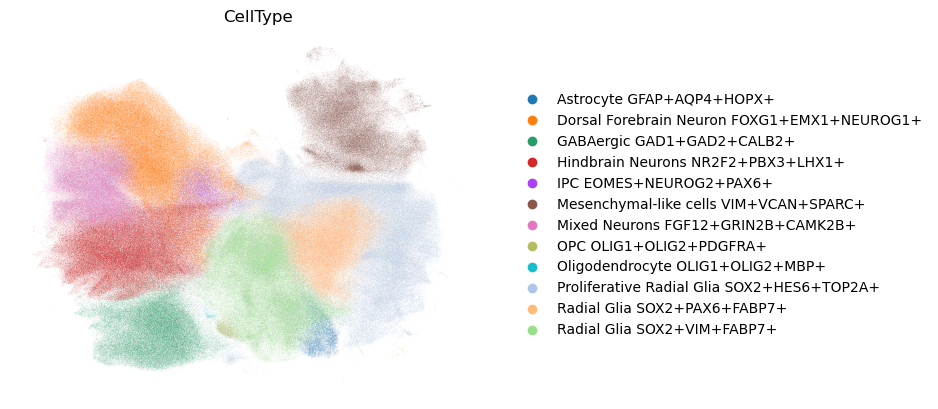

In [8]:
sc.pl.umap(adata, color='CellType', frameon=False)

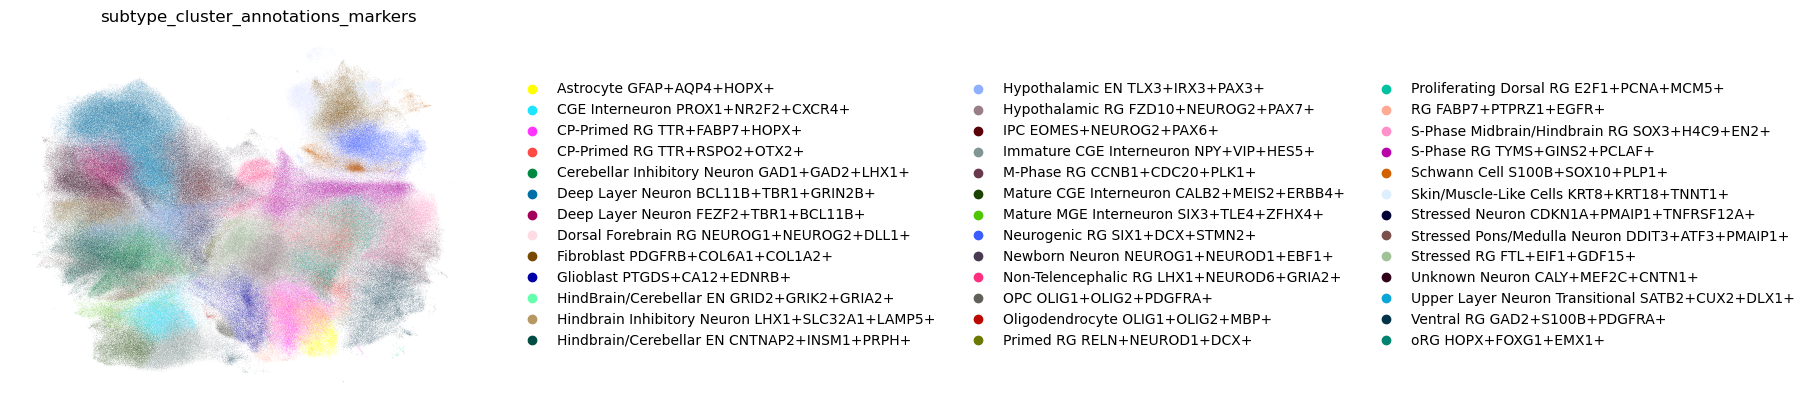

In [9]:
sc.pl.umap(adata, color='subtype_cluster_annotations_markers', frameon=False)

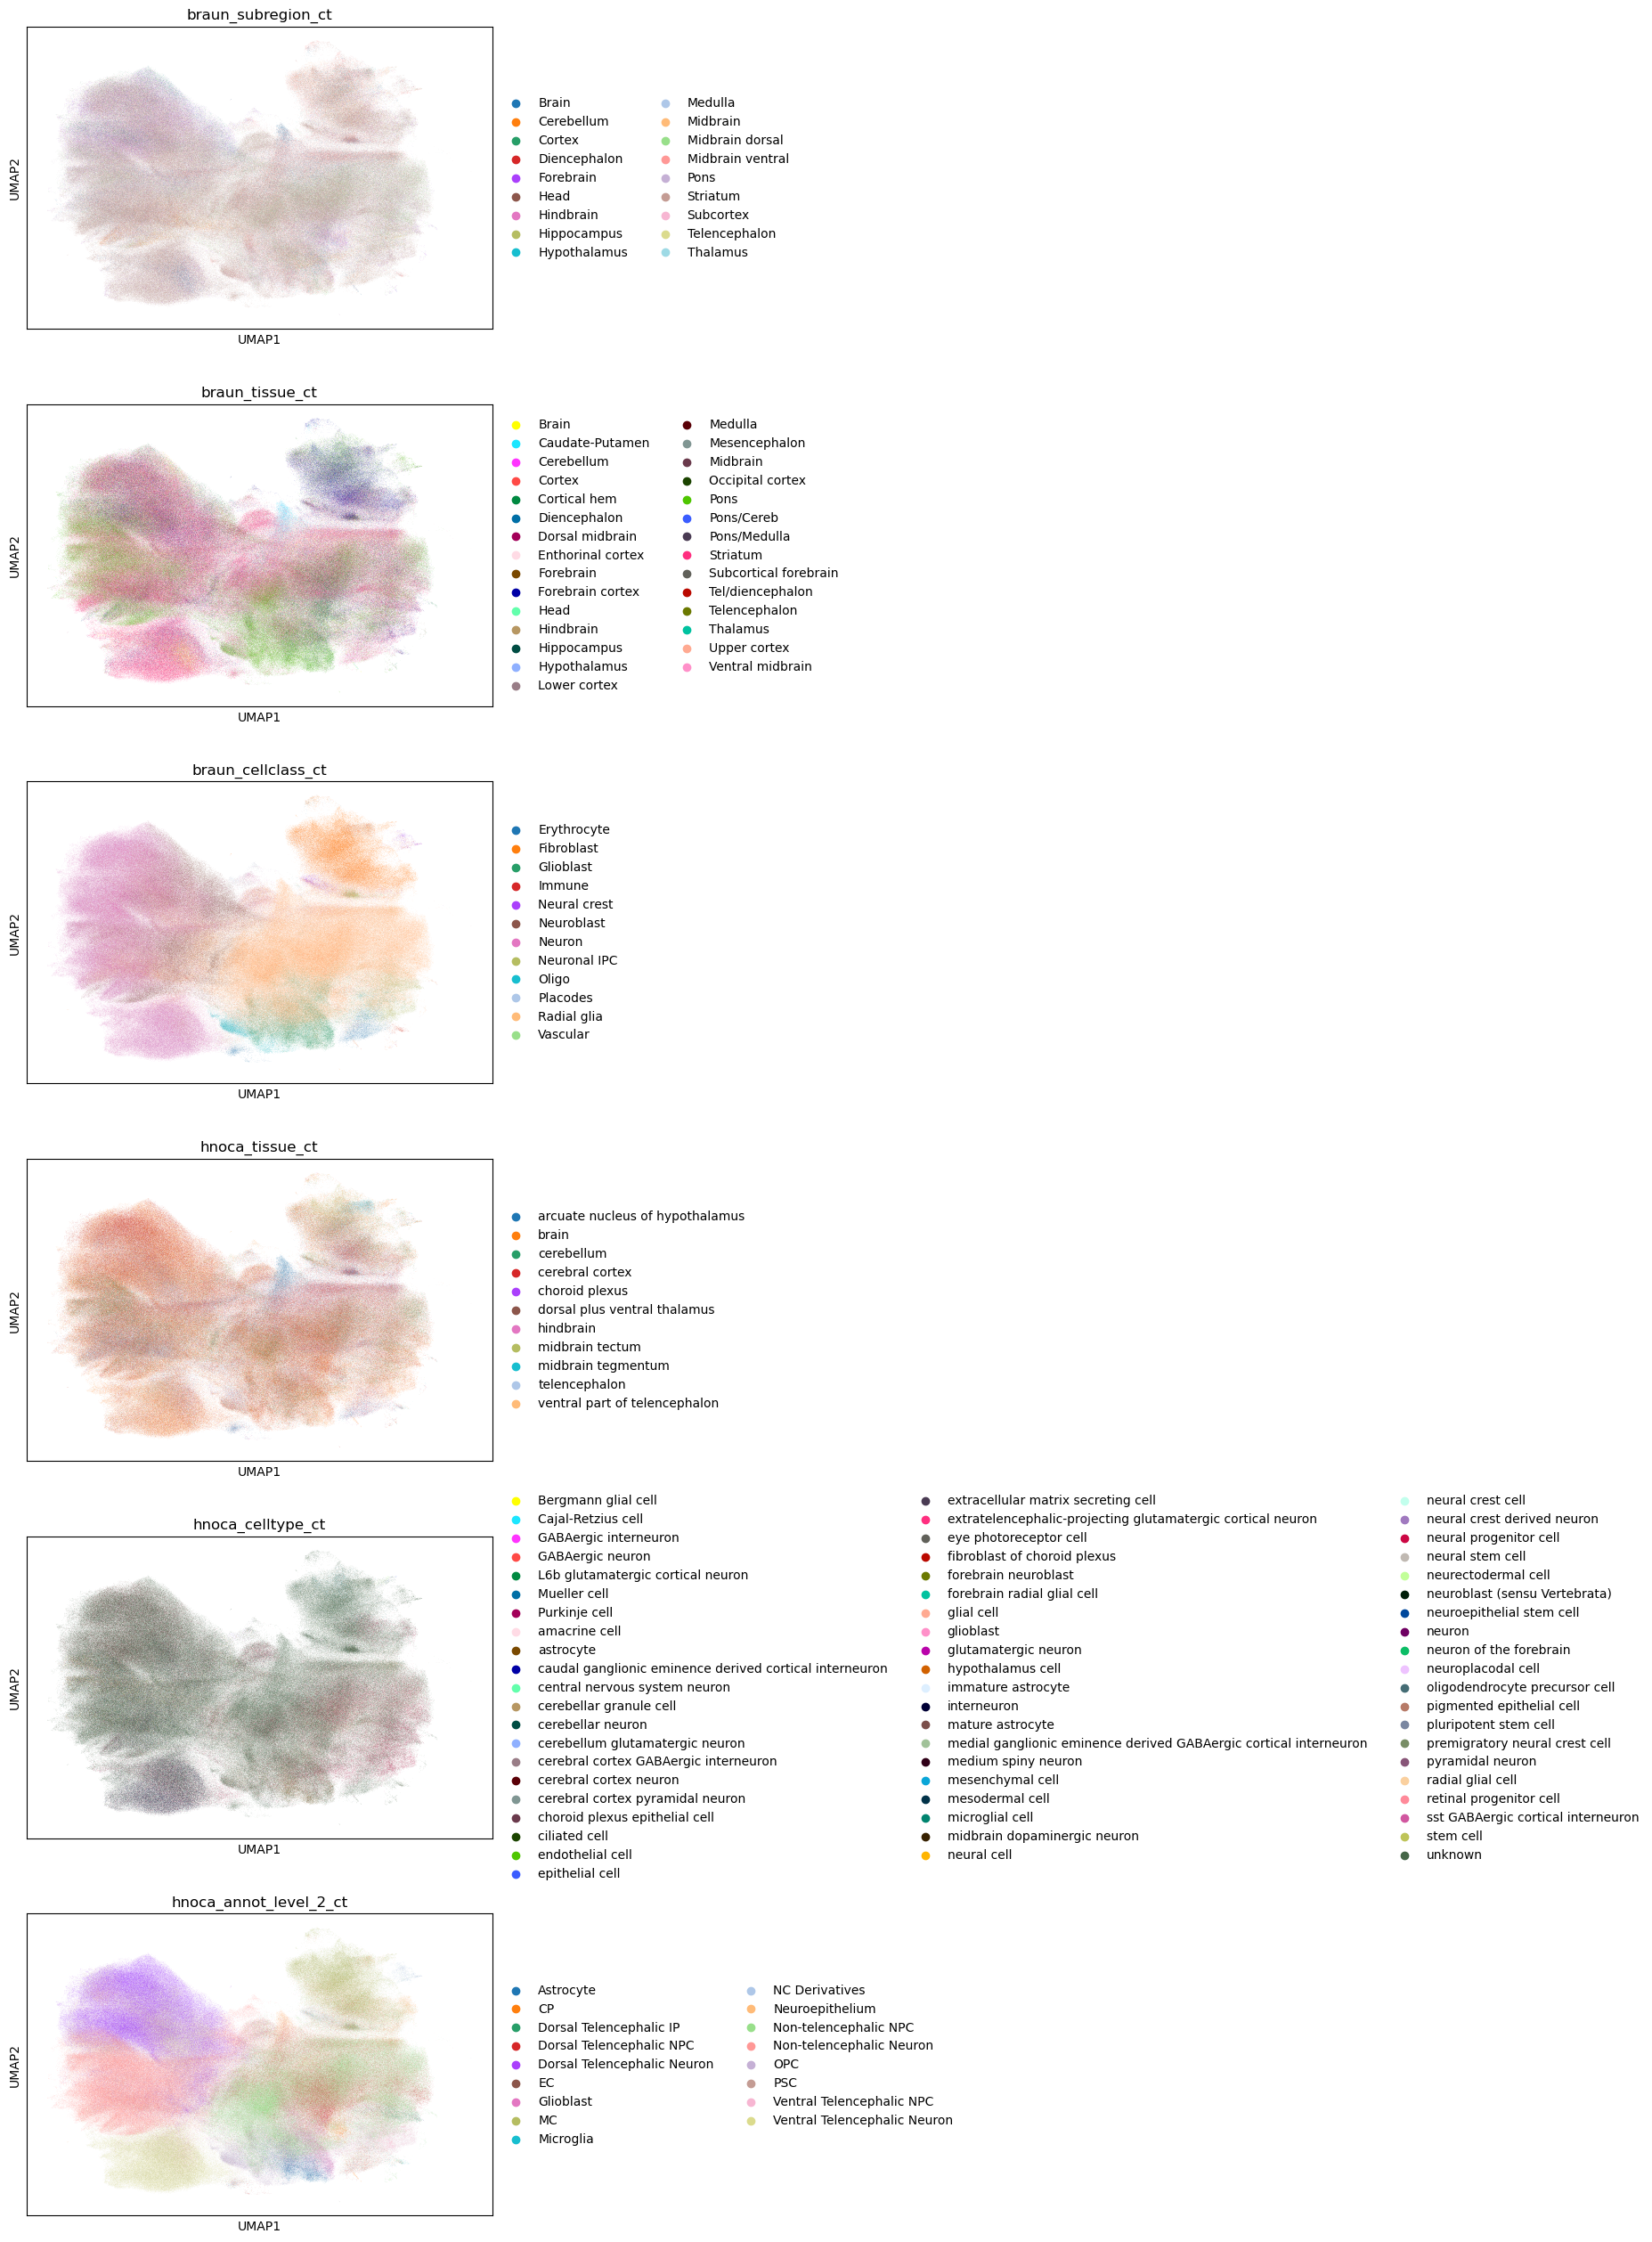

In [10]:
sc.pl.umap(adata, color=['braun_subregion_ct', 'braun_tissue_ct',
                           'braun_cellclass_ct',  'hnoca_tissue_ct',
                           'hnoca_celltype_ct', 'hnoca_annot_level_2_ct'], ncols=1)

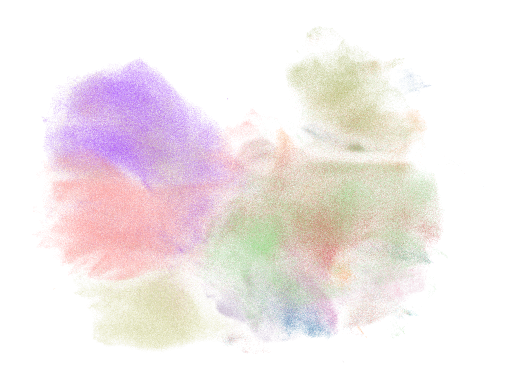

In [44]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='hnoca_annot_level_2_ct', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_SCZ_Atlas_HNOCA_L2_Preds_UMAP_no_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)

plt.show()

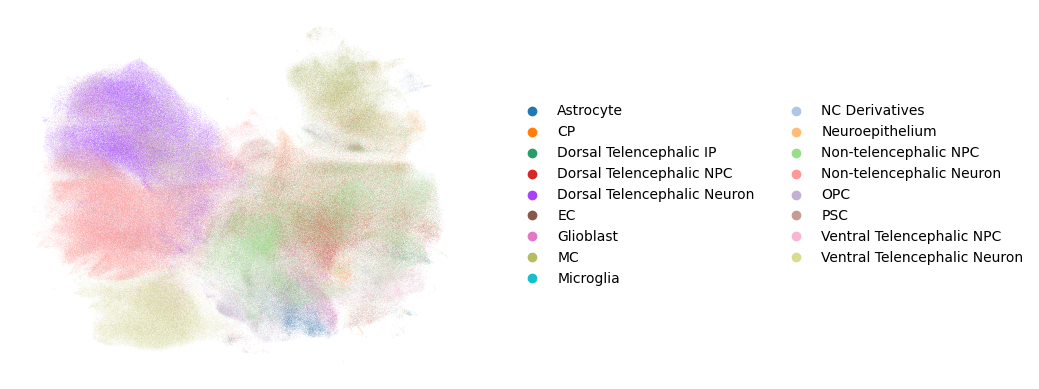

In [49]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='hnoca_annot_level_2_ct', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_SCZ_Atlas_HNOCA_L2_Preds_UMAP_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)

plt.show()

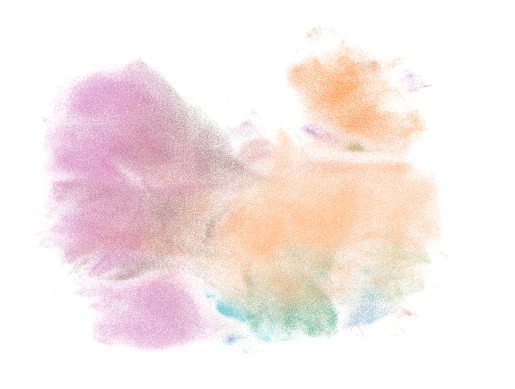

In [45]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='braun_cellclass_ct', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_SCZ_Atlas_Braun_CellClass_Preds_UMAP_no_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)

plt.show()

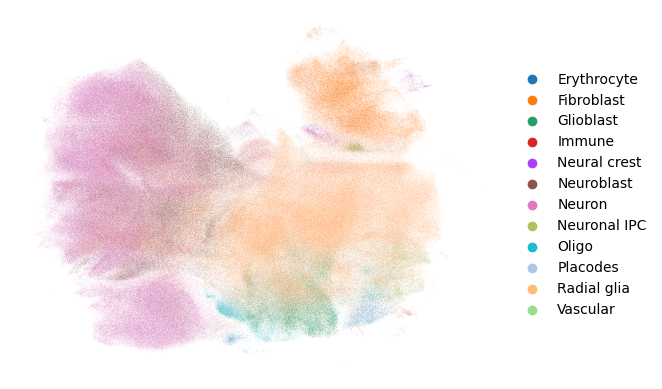

In [48]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='braun_cellclass_ct', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_SCZ_Atlas_Braun_CellClass_Preds_UMAP_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)

plt.show()

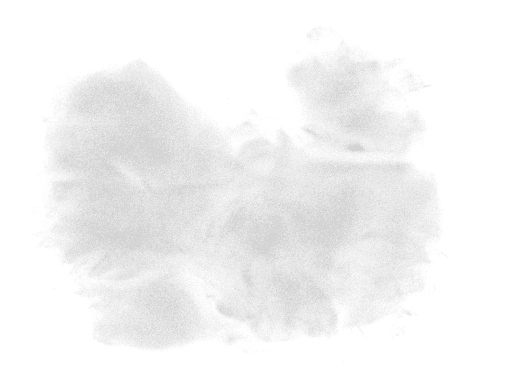

In [47]:
fig, ax = plt.subplots()

sc.pl.umap(adata, ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_SCZ_Atlas_No_Color.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)

plt.show()

In [30]:
def sankey_from_anndata(
    adata,
    source_col,
    target_col,
    source_palette_key=None,
    target_palette_key=None,
    title="Sankey Plot",
    figsize=(600, 900),   # (width, height)
    link_color="#999999",
    save_path=None,     
    save_format="svg"):
    
    # -----------------------------
    # Build dataframe
    # -----------------------------
    
    df = adata.obs[[source_col, target_col]].copy()
    df.columns = ["source", "target"]

    flow = (
        df.groupby(["source", "target"])
          .size()
          .reset_index(name="count")
    )

    # -----------------------------
    # Nodes
    # -----------------------------
    
    source_nodes = flow["source"].unique().tolist()
    target_nodes = flow["target"].unique().tolist()
    all_nodes = source_nodes + [x for x in target_nodes if x not in source_nodes]

    node_map = {n: i for i, n in enumerate(all_nodes)}

    sources = flow["source"].map(node_map)
    targets = flow["target"].map(node_map)
    values = flow["count"]

    # -----------------------------
    # Color maps
    # -----------------------------
    
    def build_color_map(col, palette_key):
        if palette_key and palette_key in adata.uns:
            cats = adata.obs[col].astype("category").cat.categories
            palette = adata.uns[palette_key]
            return dict(zip(cats, palette))
        return {}

    source_color_map = build_color_map(source_col, source_palette_key)
    target_color_map = build_color_map(target_col, target_palette_key)

    # -----------------------------
    # Node colors
    # -----------------------------
    node_colors = []
    for node in all_nodes:
        if node in source_color_map:
            node_colors.append(source_color_map[node])
        elif node in target_color_map:
            node_colors.append(target_color_map[node])
        else:
            node_colors.append("#cccccc")

    # -----------------------------
    # Link colors (by source)
    # -----------------------------
    link_colors = [
        source_color_map.get(s, link_color)
        for s in flow["source"]
    ]

    # -----------------------------
    # Plot
    # -----------------------------
    fig = go.Figure(go.Sankey(
        arrangement="snap",

        node=dict(
            pad=10,
            thickness=18,
            line=dict(color="black", width=0.5),
            label=all_nodes,
            color=node_colors,
        ),

        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
            hovertemplate="%{source.label} → %{target.label}<br>Cells: %{value}<extra></extra>"
        )
    ))

    fig.update_layout(
        title=title,
        font_size=10,
        width=figsize[0],
        height=figsize[1]
    )


    # -----------------------------
    # Save option
    # -----------------------------
    if save_path is not None:
    
        fig.update_layout(title_text=title, font_size=12)
        fig.write_image(save_path)

    fig.show()
    return fig

In [31]:
fig = sankey_from_anndata(
    adata,
    "CellType",
    "hnoca_annot_level_2_ct",
    source_palette_key="CellType_colors",
    figsize=(700, 1500),
    title="CellType → HNOCA Level 2",
    save_path='/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_CellType_HNOCA_Level_2_sanky.svg')

/tmp/ipykernel_1389161/4186713313.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1389161/4186713313.py:108: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [34]:
fig = sankey_from_anndata(
    adata,
    "CellType",
    "braun_cellclass_ct",
    source_palette_key="CellType_colors",
    target_palette_key="braun_cellclass_ct",
    figsize=(700, 1500),
    title="CellType → Braun CellClass",
    save_path='/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_CellType_Braun_CellClass_sanky.svg')

/tmp/ipykernel_1389161/4186713313.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1389161/4186713313.py:108: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [39]:
fig = sankey_from_anndata(
    adata,
    "CellType",
    "subtype_cluster_annotations_markers",
    source_palette_key="CellType_colors",
    target_palette_key="subtype_cluster_annotations_markers",
    figsize=(700, 2000),
    title="CellType → Subtype",
    save_path='/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_CellType_Subtype_sanky.svg')

/tmp/ipykernel_1389161/4186713313.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1389161/4186713313.py:108: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [ ]:
del adata
gc.collect()

In [2]:
## Braun Adata ##

braun_adata = sc.read_h5ad('/home/deepak/datasets/developing_neocortex/Braun_Linnarsson_2023/human_dev_clustered.h5ad')

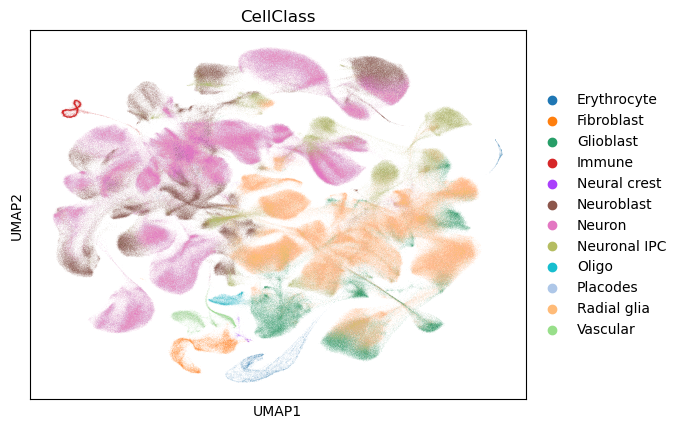

In [3]:
sc.pl.umap(braun_adata, color='CellClass')

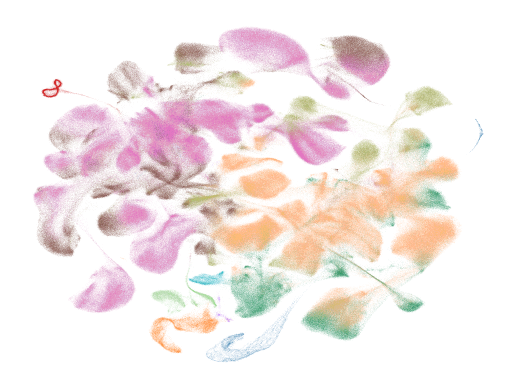

In [7]:
fig, ax = plt.subplots()

sc.pl.umap(braun_adata, color='CellClass', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_Braun_UMAP_no_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)
plt.show()

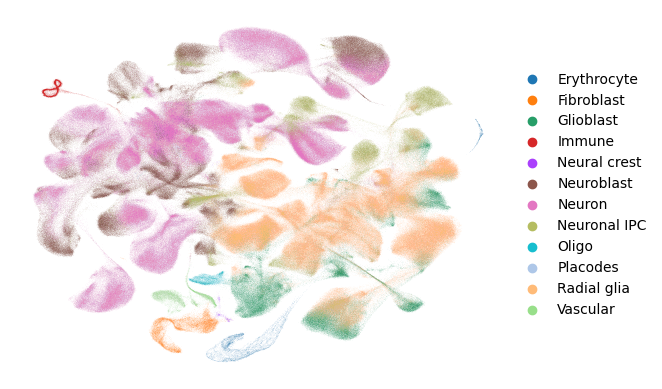

In [8]:
fig, ax = plt.subplots()

sc.pl.umap(braun_adata, color='CellClass', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_Braun_UMAP.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)
plt.show()

In [9]:
del braun_adata
gc.collect()

6132

In [10]:
## HNOCA ##
## Treutlein Dataset ##

hnoca = sc.read_h5ad('/home/deepak/datasets/organoid_atlases/He_Treutlein_2024/hnoca_extended.h5ad')

In [13]:
hnoca.obsm

AxisArrays with keys: X_scpoli, X_umap_scpoli

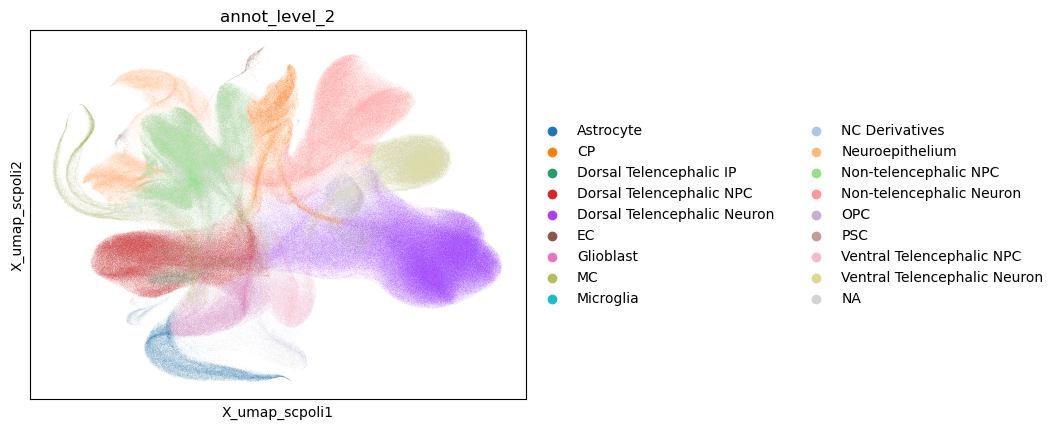

In [15]:
sc.pl.embedding(hnoca, basis='X_umap_scpoli', color='annot_level_2')

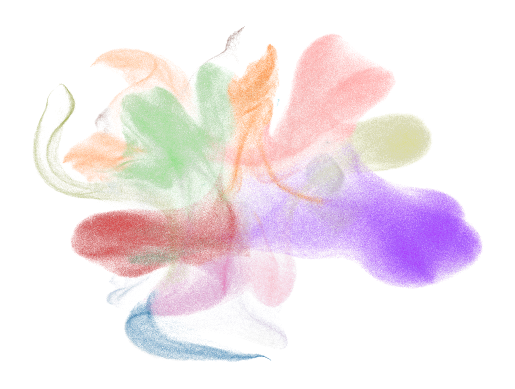

In [16]:
fig, ax = plt.subplots()

sc.pl.embedding(hnoca, basis='X_umap_scpoli', color='annot_level_2', ax=ax, show=False, legend_loc=None)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_HNOCA_UMAP_no_legend.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)
plt.show()

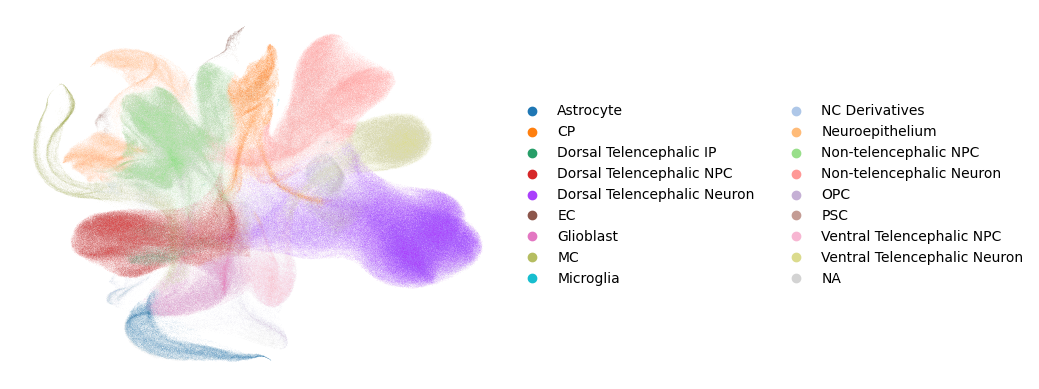

In [17]:
fig, ax = plt.subplots()

sc.pl.embedding(hnoca, basis='X_umap_scpoli', color='annot_level_2', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Atlas_Consensus_HNOCA_UMAP.png", 
            dpi=500, bbox_inches="tight", pad_inches=0, transparent=True,)
plt.show()